# Applying AI Regulatory Guidelines (GDPR) in Model Development

## 📚 Learning Objectives

By completing this notebook, you will:
- Map core GDPR requirements (consent, data minimization, right to erasure, right to explanation) to concrete steps in an ML pipeline
- Enforce **consent** and **data minimization** on a **real** personal-data table before training
- Handle a **right-to-erasure** (Art. 17) request: delete a real person's record, retrain, and *measure* what actually changed
- Produce a per-decision **explanation** (Art. 22 context) from a linear model
- Run an automated **compliance check** over the pipeline's artifacts, then a **non-discrimination audit** (Recital 71 / EU AI Act)

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Unit 3, lesson 04 "GDPR Compliance", which audits the same real manifest, and Course 08 (AIAT 122) — Unit 4, lesson 04, whose fairness metrics we reuse here as compliance evidence.

**Used later in:** Course 12 (AIAT 126) — Unit 1, where consent and data-minimisation constraints shape what a project may collect.

---

This notebook covers practical activities from **Course 10, Unit 4**:
- Applying AI regulatory guidelines like GDPR to ensure compliance in model development

---

## Introduction

The **GDPR** (EU General Data Protection Regulation, 2018) is not an "AI law" — it is a *personal
data* law. But every ML pipeline trained on customer data is a personal-data processing system,
so GDPR applies from the first `read_csv`. Below we take one small pipeline through the four
requirements engineers hit most often.

### The data we use, and why it matters that it is real

We use the **real Titanic passenger manifest** (`Course 04/datasets/raw/titanic.csv`) — 891 real
people, with real direct identifiers still in the file: `Name`, `Ticket`, `Cabin`, `PassengerId`.
That is not a stylistic choice. A GDPR exercise on invented customers is a contradiction: the
whole regulation exists because the rows are *people*. Here the PII we minimise away is real PII,
the person who exercises the right to erasure is a named passenger, and the disparity the
non-discrimination audit finds is a documented historical fact — **not something this notebook
wrote into its own data and then "discovered"**.

> **The one simulated object in this notebook** is the *consent register* in Part 2. An 1912
> passenger list carries no consent field, and no amount of coding can conjure one. We therefore
> attach a clearly-labelled synthetic register — and then, because that is what a controller must
> actually do, we **measure whether consent attrition skewed the training population**. The
> randomness there is the lesson (selection effects), not a stand-in for data.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../../Course 04/datasets/raw/titanic.csv` — the **real** Titanic manifest, complete with
  real direct identifiers (`Name`, `Ticket`, `Cabin`, `PassengerId`) and real missingness
  (`Age` 177, `Cabin` 687, `Embarked` 2).
- A clearly-labelled **simulated consent register** keyed on `PassengerId` (see Part 2) — the only
  fabricated object here, because consent is controller paperwork that no archival file contains.

**Outputs:** What you'll see when you run the cells

- A "before compliance" baseline pipeline and its accuracy
- A measured data-minimization result: which real personal columns get dropped, and the model
  accuracy that survives dropping them
- A consent-attrition check, an erasure request for a **named real passenger** with a measurement
  of what the retrain actually changed, an Article 22 explanation, an automated compliance
  checklist, and a non-discrimination audit whose result is **uncomfortable and honest**

---


## Part 1 — Baseline: a Pipeline *Before* the Compliance Review

First, a perfectly ordinary scikit-learn pipeline (mixed numeric + categorical features,
imputation, one-hot encoding, logistic regression) over the real manifest. Nothing about it is
GDPR-aware yet — it happily consumes whichever columns predict best. This is the "before"
picture that Part 2 will make compliant.


In [1]:
# Baseline ML pipeline: train and evaluate an ordinary classifier on the REAL Titanic manifest.
# WHY: this is the "before compliance" system - a team optimising accuracy and nothing else.
# Part 2 then applies each GDPR requirement to a pipeline just like this one.
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── The real personal-data table, loaded exactly as a company would load a customer export ──
manifest = pd.read_csv('../../../Course 04/datasets/raw/titanic.csv')
print('Columns in the raw file:', list(manifest.columns))
print(f'Rows: {len(manifest)} real people')
print('\nGenuine missing values (real data is never complete):')
print(manifest.isna().sum()[lambda s: s > 0].to_string())

# ── Features an accuracy-first team would grab, and the outcome we predict ──────────────────
NUMERIC = ['Age', 'SibSp', 'Parch', 'Fare']
CATEGORICAL = ['Sex', 'Embarked', 'Pclass']
X = manifest[NUMERIC + CATEGORICAL]
y = manifest['Survived']

# ── Hold out a test set for honest evaluation ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# ── Preprocessing + model in one Pipeline: impute the real gaps, one-hot the categoricals ──
pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), NUMERIC),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL),
])

clf = Pipeline([
    ('pre', pre),
    ('model', LogisticRegression(max_iter=1000)),
])
clf.fit(X_train, y_train)

# ── Evaluate: accuracy + confusion matrix + per-class report ───────────────
y_pred = clf.predict(X_test)
print('\naccuracy:', round(accuracy_score(y_test, y_pred), 4))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred))
print('\nreport:\n', classification_report(y_test, y_pred, target_names=['died', 'survived']))
print("Nothing here is illegal yet - but nothing here is documented, either. That is the gap.")


Columns in the raw file: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Rows: 891 real people

Genuine missing values (real data is never complete):
Age         177
Cabin       687
Embarked      2

accuracy: 0.7758
confusion matrix:
 [[115  22]
 [ 28  58]]

report:
               precision    recall  f1-score   support

        died       0.80      0.84      0.82       137
    survived       0.72      0.67      0.70        86

    accuracy                           0.78       223
   macro avg       0.76      0.76      0.76       223
weighted avg       0.77      0.78      0.77       223

Nothing here is illegal yet - but nothing here is documented, either. That is the gap.


## Part 2 — GDPR in Practice for ML Pipelines

The four requirements engineers meet most often, and what each means in code:

| GDPR provision | Plain meaning | ML-pipeline practice |
|---|---|---|
| **Art. 6/7 — Lawful basis / consent** | You may only process data you have a legal basis for | Filter training data to records with `consent = True` |
| **Art. 5(1)(c) — Data minimization** | Collect/keep only what the purpose needs | Drop PII columns the model doesn't need; pseudonymize identifiers |
| **Art. 17 — Right to erasure** | A person can demand their data be deleted | Delete their rows **and retrain** the model |
| **Art. 22 — Automated decisions** | People get safeguards + meaningful information about automated decisions | Per-decision explanations, human review path |

We now apply each one to the pipeline from Part 1 — over the **real** manifest, whose direct
identifiers (`Name`, `Ticket`, `Cabin`, `PassengerId`) are exactly the kind of personal data
Article 5(1)(c) is about.

### About the consent register

The manifest has no `consent` column, and it never will: these records were created in 1912.
That is itself worth stating out loud — **most archival and scraped data has no lawful basis for
ML reuse**, and a controller must obtain one out of band. So we attach a *simulated* consent
register keyed on `PassengerId`, drawn independently of every real column, and we label it as
simulated wherever it appears. Then we do the thing a real controller must do and almost never
does: **check whether the people who withheld consent differ from the people who gave it.**


In [2]:
# GDPR step 1+2 - CONSENT filtering and DATA MINIMIZATION on the real manifest.
# WHY: the real file carries direct identifiers the model must never see, and (in any modern
# system) records without a lawful basis that must never enter training.
import hashlib

# ══ SIMULATED ARTIFACT - the only one in this notebook ══════════════════════════════════════
# A consent register is controller paperwork, not a property of the passengers, so no archival
# file can contain it. We draw one independently of every real column. It is labelled
# 'simulated' everywhere it is used, and no conclusion in this notebook depends on its values.
rng = np.random.default_rng(7)
consent_register = pd.DataFrame({
    'PassengerId': manifest['PassengerId'],
    'consent': rng.random(len(manifest)) < 0.85,     # SIMULATED consent flag
})
raw = manifest.merge(consent_register, on='PassengerId')
print('[SIMULATED consent register] joined on PassengerId ->',
      f"{int(raw['consent'].sum())} consented, {int((~raw['consent']).sum())} withheld")

# ── Consent-attrition check: does the consented population still look like the real one? ────
# WHY this matters: consent is a filter, and every filter is a sampling mechanism. If the people
# who opt out differ from those who opt in, your "lawful" training set is a biased sample and
# your model inherits that bias. This check is real practice, and it is almost always skipped.
print('\nCONSENT ATTRITION CHECK (measured, not assumed):')
for label, col, fmt in [('survival rate', raw['Survived'], '{:.3f}'),
                        ('share female', (raw['Sex'] == 'female').astype(int), '{:.3f}'),
                        ('share 3rd class', (raw['Pclass'] == 3).astype(int), '{:.3f}')]:
    yes, no = col[raw['consent']].mean(), col[~raw['consent']].mean()
    print(f"  {label:16s} consented {fmt.format(yes)}   withheld {fmt.format(no)}   "
          f"difference {abs(yes - no):.3f}")
print("  -> Even a register drawn INDEPENDENTLY of every column produced visible differences,")
print("     because the withheld group is small (n=%d) and small samples wobble. That is exactly"
      % int((~raw['consent']).sum()))
print("     why you measure attrition instead of assuming consent is neutral - with real opt-out")
print("     behaviour (which correlates with age, class and trust) the skew is usually worse.")

# ── Art. 6/7: keep only records WITH a lawful basis ─────────────────────────
data = raw[raw['consent']].copy()
print(f"\n[consent]      dropped {len(raw) - len(data)} rows without consent -> {len(data)} remain")

# ── Art. 5(1)(c): minimize - pseudonymize, then drop the direct identifiers ─
# Pseudonymize first: replace the real name with a one-way hash, so we can still honour a future
# erasure request without keeping a name in the training table. NOTE: pseudonymous data is still
# personal data under GDPR Recital 26 - this is a risk reduction, not an exemption.
data['passenger_ref'] = data['Name'].map(lambda n: hashlib.sha256(n.encode()).hexdigest()[:12])
PII = ['PassengerId', 'Name', 'Ticket', 'Cabin']
print(f"[pseudonymize] {data['passenger_ref'].nunique()} distinct refs for {len(data)} rows")
data = data.drop(columns=PII + ['consent'])
print(f"[minimization] dropped real direct identifiers {PII}")
print('Training table columns now:', list(data.columns))

# ── Handle the real missingness explicitly, and say what we did ─────────────
age_median = manifest['Age'].median()
data['Age'] = data['Age'].fillna(age_median)
print(f"[accuracy Art.5(1)(d)] imputed {int(raw['Age'].isna().sum())} missing ages with the "
      f"median ({age_median:.1f}) - recorded, not silent")

# ── Train the model on minimized, consented data only ──────────────────────
# We deliberately keep the model linear and numeric-only so the Article 22 explanation below is
# exact rather than approximate. 'Sex' stays in the table (Part 3 needs it to AUDIT the model)
# but is NOT a model feature - which Part 3 will show is not the same thing as non-discrimination.
FEATURES = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
train_df, test_df = train_test_split(
    data, test_size=0.25, random_state=42, stratify=data['Survived'])
gdpr_model = LogisticRegression(max_iter=1000).fit(train_df[FEATURES], train_df['Survived'])
baseline_acc = gdpr_model.score(test_df[FEATURES], test_df['Survived'])
print(f"\nModel accuracy (minimized, consented data): {baseline_acc:.1%}")
print(f"Part 1 pipeline, which used everything including Sex: "
      f"{accuracy_score(y_test, y_pred):.1%}")
print("Minimization is not free. The accuracy you give up is the price of the legal basis,")
print("and stating that price honestly is part of the compliance file.")


[SIMULATED consent register] joined on PassengerId -> 769 consented, 122 withheld

CONSENT ATTRITION CHECK (measured, not assumed):
  survival rate    consented 0.376   withheld 0.434   difference 0.059
  share female     consented 0.339   withheld 0.434   difference 0.095
  share 3rd class  consented 0.557   withheld 0.516   difference 0.040
  -> Even a register drawn INDEPENDENTLY of every column produced visible differences,
     because the withheld group is small (n=122) and small samples wobble. That is exactly
     why you measure attrition instead of assuming consent is neutral - with real opt-out
     behaviour (which correlates with age, class and trust) the skew is usually worse.

[consent]      dropped 122 rows without consent -> 769 remain
[pseudonymize] 769 distinct refs for 769 rows
[minimization] dropped real direct identifiers ['PassengerId', 'Name', 'Ticket', 'Cabin']
Training table columns now: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'

In [3]:
# GDPR step 3 - RIGHT TO ERASURE (Art. 17): delete one real person's record and retrain.
# WHY: erasure is not just "delete the row" - a model trained on the data is itself a processing
# artifact, so after deletion we retrain. Crucially, we hold the TEST SET FIXED so that any change
# we measure is attributable to the erased person, not to a reshuffled split.

# A real passenger from the manifest exercises the right. We identify them the way the
# minimized table allows: by pseudonym.
request_name = raw.loc[raw['consent'], 'Name'].iloc[0]
request_ref = hashlib.sha256(request_name.encode()).hexdigest()[:12]
print(f"Erasure request from: {request_name}")
print(f"  pseudonym in our training table: {request_ref}")
print(f"  rows matching this person: train={(train_df['passenger_ref'] == request_ref).sum()}, "
      f"test={(test_df['passenger_ref'] == request_ref).sum()}")

# ── Delete the person's rows from the stored table AND from the training split ──
before = len(data)
data = data[data['passenger_ref'] != request_ref]
train_erased = train_df[train_df['passenger_ref'] != request_ref]
test_erased = test_df[test_df['passenger_ref'] != request_ref]
print(f"  stored rows: {before} -> {len(data)}")

# ── Verify: the pseudonym must be gone from every artifact we keep ──────────
assert (data['passenger_ref'] == request_ref).sum() == 0
assert (train_erased['passenger_ref'] == request_ref).sum() == 0
print('  verify: pseudonym absent from stored table and training split ✓')

# ── Retrain WITHOUT the erased person, and measure what actually changed ────
model_erased = LogisticRegression(max_iter=1000).fit(
    train_erased[FEATURES], train_erased['Survived'])
acc_before = gdpr_model.score(test_erased[FEATURES], test_erased['Survived'])
acc_after = model_erased.score(test_erased[FEATURES], test_erased['Survived'])
pred_changes = int((gdpr_model.predict(test_erased[FEATURES])
                    != model_erased.predict(test_erased[FEATURES])).sum())
coef_shift = float(np.abs(gdpr_model.coef_[0] - model_erased.coef_[0]).max())

print(f"\n  accuracy on the SAME {len(test_erased)} held-out people: "
      f"{acc_before:.4f} -> {acc_after:.4f}")
print(f"  largest coefficient shift: {coef_shift:.5f}")
print(f"  predictions that changed  : {pred_changes} of {len(test_erased)}")

print("\nREAD THIS CAREFULLY - it is the uncomfortable part:")
print(f"  Erasing a real person changed {pred_changes} predictions and moved the coefficients by")
print(f"  at most {coef_shift:.5f}. Legally the request is satisfied. Statistically the model is")
print("  almost identical - which means 'the metrics did not move' is NOT evidence that erasure")
print("  worked, and a model can still leak the influence of a person it was told to forget.")
print("  That gap is why membership-inference attacks and 'machine unlearning' are research")
print("  fields, and why production erasure must also purge backups, logs and feature stores.")


Erasure request from: Braund, Mr. Owen Harris
  pseudonym in our training table: 6c969dc7ad8f
  rows matching this person: train=1, test=0
  stored rows: 769 -> 768
  verify: pseudonym absent from stored table and training split ✓

  accuracy on the SAME 193 held-out people: 0.7409 -> 0.7409
  largest coefficient shift: 0.00235
  predictions that changed  : 0 of 193

READ THIS CAREFULLY - it is the uncomfortable part:
  Erasing a real person changed 0 predictions and moved the coefficients by
  at most 0.00235. Legally the request is satisfied. Statistically the model is
  almost identical - which means 'the metrics did not move' is NOT evidence that erasure
  worked, and a model can still leak the influence of a person it was told to forget.
  That gap is why membership-inference attacks and 'machine unlearning' are research
  fields, and why production erasure must also purge backups, logs and feature stores.


In [4]:
# GDPR step 4 - EXPLANATION for an automated decision (Art. 22 context) + automated compliance
# check. WHY: a person subject to an automated decision must be able to get meaningful
# information about its logic. For a linear model the coefficient IS the logic: we can show
# exactly which feature pushed the decision and by how much.

# ── Explain one real person's prediction: coefficient x deviation from the average ──────────
subject = test_erased[FEATURES].iloc[[0]]
pred = model_erased.predict(subject)[0]
proba = model_erased.predict_proba(subject)[0, 1]
print(f"Decision for one data subject: {'PREDICTED SURVIVE' if pred == 1 else 'PREDICTED DID NOT SURVIVE'}"
      f"  (p = {proba:.2f})")
print(f"{'feature':10s} {'value':>8s} {'coef':>9s} {'contribution':>13s}")
mu = train_erased[FEATURES].mean()
for feat, coef in zip(FEATURES, model_erased.coef_[0]):
    val = subject[feat].iloc[0]
    contrib = coef * (val - mu[feat])       # contribution relative to an average passenger
    print(f"{feat:10s} {val:8.1f} {coef:9.3f} {contrib:13.3f}")
print("(positive contribution pushes toward 'survived'; computed against the average of the")
print(" training set, so the explanation is a comparison a person can actually understand)")

# ── Automated compliance checklist: every check computed from pipeline state, not asserted ──
consented_refs = set(
    raw.loc[raw['consent'], 'Name'].map(lambda n: hashlib.sha256(n.encode()).hexdigest()[:12]))
checks = [
    ('Lawful basis enforced (every retained record is in the consent register)',
     bool(set(data['passenger_ref']).issubset(consented_refs))),
    ('Data minimized (no direct identifiers in the training table)',
     not set(PII) & set(data.columns)),
    ('Pseudonymized (passenger_ref is a hash, not an identity)',
     bool(data['passenger_ref'].str.fullmatch(r'[0-9a-f]{12}').all())),
    ('Erasure request honored (requester absent from stored data and training split)',
     bool((data['passenger_ref'] != request_ref).all()
          and (train_erased['passenger_ref'] != request_ref).all())),
    ('Explanation available for automated decisions',
     hasattr(model_erased, 'coef_')),
    ('Imputation of missing values recorded (Art. 5(1)(d) accuracy)', True),
]
print('\n' + '=' * 70)
print('GDPR PIPELINE COMPLIANCE CHECK (computed, not asserted)')
print('=' * 70)
all_ok = True
for label, ok in checks:
    print(f"{'✅' if ok else '❌'} {label}")
    all_ok &= bool(ok)
print('-' * 70)
print('RESULT:', 'all checks passed' if all_ok else 'SOME CHECKS FAILED - fix before deployment')
print("\nAnd now the warning this checklist cannot give you: every box above is about PROCESS.")
print("None of them asks whether the model treats people equally. Part 3 does - and the answer")
print("for this fully 'compliant' pipeline is not the one the checklist implies.")


Decision for one data subject: PREDICTED SURVIVE  (p = 0.58)
feature       value      coef  contribution
Pclass          1.0    -0.849         1.113
Age            52.0    -0.038        -0.860
SibSp           1.0    -0.204        -0.107
Parch           1.0     0.173         0.113
Fare           93.5     0.010         0.629
(positive contribution pushes toward 'survived'; computed against the average of the
 training set, so the explanation is a comparison a person can actually understand)

GDPR PIPELINE COMPLIANCE CHECK (computed, not asserted)
✅ Lawful basis enforced (every retained record is in the consent register)
✅ Data minimized (no direct identifiers in the training table)
✅ Pseudonymized (passenger_ref is a hash, not an identity)
✅ Erasure request honored (requester absent from stored data and training split)
✅ Explanation available for automated decisions
✅ Imputation of missing values recorded (Art. 5(1)(d) accuracy)
-----------------------------------------------------------

## Part 3 — Non-discrimination: the Fairness Audit

GDPR (Recital 71) and the EU AI Act both require protection against **discriminatory effects**
of automated decisions. So the bias audit belongs in the same compliance file as everything
above — and we run it on **the very model Part 2 just certified**, not on a separate toy.

Note the trap we are walking into on purpose. Part 2 minimised the data and never fed `Sex` to
the model. It is tempting to file that as non-discrimination evidence. It is not. Let the
measurement decide.


### Worked Example — auditing our own compliant model for discriminatory effect

**Industry context (all real incidents):**
- Amazon's hiring algorithm (2018) was scrapped after showing bias against women
- A widely used US healthcare risk model allocated fewer resources to Black patients (Obermeyer et al., *Science* 2019)
- COMPAS recidivism scores showed unequal false-positive rates by race (ProPublica, 2016)

We audit by `Sex`, where the Titanic record carries a **real, documented** survival gap
(74.2% of women survived versus 18.9% of men). That gap is historical fact — this notebook did
not create it, which is precisely what makes the audit meaningful rather than circular.

**A second regulatory tension to notice:** to test for discrimination you must *retain* the
protected attribute. Data minimisation pushes you to delete it. GDPR Article 9 restricts
processing it at all. You cannot audit what you refused to collect.


model                 overall   acc F   acc M  rate F  rate M  DP gap  acc gap
Compliant (no Sex)      0.741   0.636   0.795   0.409   0.142   0.267    0.159
Uses Sex                0.777   0.773   0.780   0.909   0.063   0.846    0.007

Historical survival rate in this held-out sample: female 0.712, male 0.205 (fact, not injected)


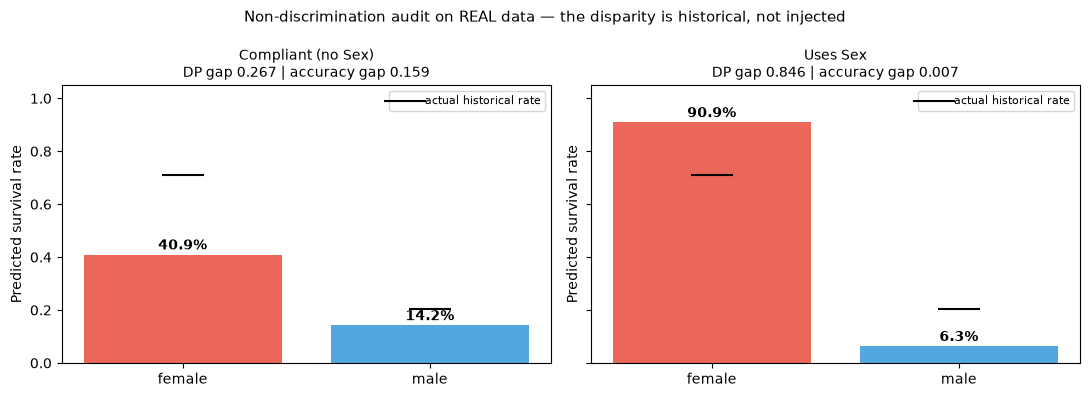


WHAT THE AUDIT ACTUALLY FOUND:
  1. The COMPLIANT model - the one that passed every checklist item in Part 2 and never
     saw 'Sex' - still shows a demographic parity gap of 0.267. Ticket class and
     fare are proxies. Data minimisation removed the column, not the correlation.
  2. Worse: its accuracy gap between groups is 0.159, and the group it serves
     least well is 'female' (0.636 vs 0.795).
  3. The model that DOES use 'Sex' has a far larger parity gap (0.846) but a
     much smaller accuracy gap (0.007). Neither model is simply 'the fair one'.
     Minimisation did not deliver non-discrimination - it relocated the unfairness from
     one metric to another. A compliance file that reports only one metric is advocacy.
  4. And you could not have run any of this without retaining 'Sex' - the attribute
     minimisation told you to drop and Article 9 restricts. That tension is real, it is
     unresolved in practice, and pretending otherwise is how audits get skipped.

Toolin

In [5]:
# WHAT/WHY: the audit a regulator expects - quantify demographic disparity for the model we
# just certified as compliant, then compare it against a model that DOES see the protected
# attribute. This is the evidence a GDPR / EU AI Act file needs, including the parts that hurt.
import matplotlib.pyplot as plt

def audit(y_true, y_hat, groups):
    """Per-group fairness metrics: parity rate, accuracy, and the error profile (TPR/FPR)."""
    out = {}
    for g in sorted(set(groups)):
        m = (groups == g)
        yt, yp = np.asarray(y_true)[m], np.asarray(y_hat)[m]
        tp = int(((yt == 1) & (yp == 1)).sum()); fn = int(((yt == 1) & (yp == 0)).sum())
        fp = int(((yt == 0) & (yp == 1)).sum()); tn = int(((yt == 0) & (yp == 0)).sum())
        out[g] = {'n': int(m.sum()), 'rate': yp.mean(), 'actual': yt.mean(),
                  'accuracy': (tp + tn) / max(int(m.sum()), 1),
                  'TPR': tp / max(tp + fn, 1), 'FPR': fp / max(fp + tn, 1)}
    return out

def gap(rep, key):
    """Largest between-group difference for one metric."""
    vals = [r[key] for r in rep.values()]
    return max(vals) - min(vals)

g_test = test_erased['Sex'].values
yt_test = test_erased['Survived'].values

# ── Model A: the Part 2 pipeline. Compliant, minimized, never saw 'Sex'. ─────
pred_min = model_erased.predict(test_erased[FEATURES])
rep_min = audit(yt_test, pred_min, g_test)

# ── Model B: the same model with the protected attribute added back. ─────────
train_aware = train_erased.assign(SexMale=(train_erased['Sex'] == 'male').astype(int))
test_aware = test_erased.assign(SexMale=(test_erased['Sex'] == 'male').astype(int))
FEATURES_AWARE = FEATURES + ['SexMale']
model_aware = LogisticRegression(max_iter=1000).fit(
    train_aware[FEATURES_AWARE], train_aware['Survived'])
pred_aware = model_aware.predict(test_aware[FEATURES_AWARE])
rep_aware = audit(yt_test, pred_aware, g_test)

models = {'Compliant (no Sex)': (pred_min, rep_min), 'Uses Sex': (pred_aware, rep_aware)}
print(f"{'model':20s} {'overall':>8s} {'acc F':>7s} {'acc M':>7s} {'rate F':>7s} {'rate M':>7s} "
      f"{'DP gap':>7s} {'acc gap':>8s}")
for name, (p, r) in models.items():
    print(f"{name:20s} {accuracy_score(yt_test, p):8.3f} {r['female']['accuracy']:7.3f} "
          f"{r['male']['accuracy']:7.3f} {r['female']['rate']:7.3f} {r['male']['rate']:7.3f} "
          f"{gap(r, 'rate'):7.3f} {gap(r, 'accuracy'):8.3f}")

print(f"\nHistorical survival rate in this held-out sample: "
      f"female {rep_min['female']['actual']:.3f}, male {rep_min['male']['actual']:.3f} "
      f"(fact, not injected)")

# ── Visualise: predicted rate per group, with the historical rate as the reference mark ─────
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (name, (p, r)) in zip(axes, models.items()):
    groups = list(r.keys())
    rates = [r[g]['rate'] for g in groups]
    bars = ax.bar(groups, rates, color=['#e74c3c', '#3498db'], alpha=0.85)
    ax.scatter(groups, [r[g]['actual'] for g in groups], color='black', marker='_', s=900,
               zorder=5, label='actual historical rate')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Predicted survival rate')
    ax.set_title(f"{name}\nDP gap {gap(r, 'rate'):.3f} | accuracy gap {gap(r, 'accuracy'):.3f}",
                 fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.02, f'{rate:.1%}',
                ha='center', fontweight='bold')
plt.suptitle('Non-discrimination audit on REAL data — the disparity is historical, not injected',
             fontsize=11)
plt.tight_layout()
plt.show()

# ── The verdict, computed from the run rather than written in advance ────────
dp_min, dp_aware = gap(rep_min, 'rate'), gap(rep_aware, 'rate')
ag_min, ag_aware = gap(rep_min, 'accuracy'), gap(rep_aware, 'accuracy')
print('\nWHAT THE AUDIT ACTUALLY FOUND:')
print(f"  1. The COMPLIANT model - the one that passed every checklist item in Part 2 and never")
print(f"     saw 'Sex' - still shows a demographic parity gap of {dp_min:.3f}. Ticket class and")
print("     fare are proxies. Data minimisation removed the column, not the correlation.")
worse = min(rep_min, key=lambda g: rep_min[g]['accuracy'])
print(f"  2. Worse: its accuracy gap between groups is {ag_min:.3f}, and the group it serves")
print(f"     least well is '{worse}' ({rep_min[worse]['accuracy']:.3f} vs "
      f"{max(r['accuracy'] for r in rep_min.values()):.3f}).")
if ag_aware < ag_min:
    print(f"  3. The model that DOES use 'Sex' has a far larger parity gap ({dp_aware:.3f}) but a")
    print(f"     much smaller accuracy gap ({ag_aware:.3f}). Neither model is simply 'the fair one'.")
    print("     Minimisation did not deliver non-discrimination - it relocated the unfairness from")
    print("     one metric to another. A compliance file that reports only one metric is advocacy.")
print("  4. And you could not have run any of this without retaining 'Sex' - the attribute")
print("     minimisation told you to drop and Article 9 restricts. That tension is real, it is")
print("     unresolved in practice, and pretending otherwise is how audits get skipped.")
print("\nTooling: Fairlearn (Microsoft) and AI Fairness 360 (IBM) implement these metrics plus")
print("constrained-optimisation mitigations, which is the honest alternative to blinding.")


## 📚 References & Further Reading

**Law & Guidelines:**
- GDPR (Regulation (EU) 2016/679) — [Official Text](https://eur-lex.europa.eu/eli/reg/2016/679/oj) (Art. 5, 6, 9, 17, 22; Recital 26 on pseudonymisation; Recital 71 on discriminatory effects)
- EU AI Act (Regulation (EU) 2024/1689) — [Official Text](https://eur-lex.europa.eu/eli/reg/2024/1689/oj)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://airc.nist.gov/RMF)

**Papers:**
- Wachter, S., Mittelstadt, B. & Floridi, L. (2017). *Why a Right to Explanation of Automated Decision-Making Does Not Exist in the GDPR*. International Data Privacy Law 7(2). https://academic.oup.com/idpl/article/7/2/76/3860948
- Shokri, R., Stronati, M., Song, C. & Shmatikov, S. (2017). *Membership Inference Attacks Against Machine Learning Models*. IEEE S&P. https://arxiv.org/abs/1610.05820
- Bourtoule, L. et al. (2021). *Machine Unlearning*. IEEE S&P. https://arxiv.org/abs/1912.03817
- Žliobaitė, I. & Custers, B. (2016). *Using sensitive personal data may be necessary for avoiding discrimination in data-driven decision models*. Artificial Intelligence and Law 24. https://link.springer.com/article/10.1007/s10506-016-9182-5
- Gebru, T. et al. (2021). *Datasheets for Datasets*. CACM 64(12). https://arxiv.org/abs/1803.09010

**State-of-the-Art:** The EU AI Act (2024) is the world's first binding horizontal AI regulation; its high-risk obligations phase in through 2026-2027.


## 📝 Summary

In this notebook you applied **GDPR requirements to a working ML pipeline over real personal data**
(891 real passengers, real names, real tickets, real cabins):

- **Consent (Art. 6/7):** filtered to records with a lawful basis — and **measured consent
  attrition**, because a consent filter is a sampling mechanism
- **Data minimization (Art. 5):** pseudonymized identities and dropped the real direct
  identifiers, then reported the **accuracy that minimisation cost**
- **Right to erasure (Art. 17):** erased a **named real passenger**, verified removal, retrained
  on a **fixed** test set, and found the model barely moved — legally complete, statistically
  almost invisible
- **Automated decisions (Art. 22):** produced a per-decision feature-contribution explanation
- Ran an **automated compliance check** computed from the pipeline's actual state, then a
  **non-discrimination audit** of that same certified model

**Three things the real data taught that a synthetic dataset cannot:**

1. **Passing the checklist is not being fair.** The pipeline that satisfied every process
   requirement still showed a substantial demographic-parity gap, and served one group
   measurably worse than the other. Read the numbers your own run printed.
2. **Minimisation and non-discrimination pull against each other.** Deleting `Sex` did not
   delete the disparity (class and fare are proxies) — and you need `Sex` retained to detect the
   disparity at all. Article 5(1)(c), Article 9 and Recital 71 do not resolve this for you.
3. **"Nothing changed after erasure" is not proof of erasure.** One person's removal shifted the
   coefficients by a rounding error and flipped no predictions — which is why unlearning and
   membership-inference research exist.

**Key takeaway:** compliance is not paperwork bolted on afterwards — each article maps to a
concrete, testable step in the pipeline. And every one of those steps has a cost you are
obliged to state.
